# 04 · REINFORCE (política) vs DQN (valor) — otra familia de RL

**Curso MIA-204 · Trabajo final · Deep RL**

Hasta ahora usamos métodos **basados en valor** (DQN, Double DQN): aprenden Q(s,a) y la
acción sale del argmax (política determinista). Aquí probamos **otra familia** de la
clase 5.1: métodos **basados en política**, con **REINFORCE** (policy gradient).

REINFORCE aprende **directamente una política** π(a|s) que da *probabilidades* de acción
(política **estocástica**) y las ajusta para que las acciones que llevaron a buen retorno
se vuelvan más probables. Comparamos las dos familias en el **mismo terreno del Misti**.

Todo el código vive en `.py` (`reinforce.py`, `train_pg.py`, y el común `entorno_drl.py`,
`dqn.py`, `train.py`, `viz.py`), este notebook lo importa.

In [1]:
# ── Setup: montar Google Drive e importar el código común ──
import sys
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA = '/content/drive/Othercomputers/My Mac/dqn'
except ImportError:
    RUTA = '.'   # ejecución local desde la carpeta dqn/
sys.path.insert(0, RUTA)

try:
    import rasterio
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', '-q', 'rasterio'])

import numpy as np, torch
import matplotlib.pyplot as plt
from entorno_drl import TerrenoDRLEnv, NUM_ACCIONES
from reinforce import AgenteREINFORCE            # política (policy gradient)
from train_pg import entrenar_pg                 # su entrenamiento por episodios
from dqn import AgenteDQN                         # valor (para comparar)
from train import entrenar, pares_de_evaluacion  # entrenamiento y test de DQN
from baselines import brecha_vs_dijkstra
from datos import ruta_dem
import viz

device = 'cuda' if torch.cuda.is_available() else 'cpu'
SEMILLA = 42
np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
RUTA_DEM = ruta_dem(RUTA)
print('dispositivo:', device, '| DEM:', RUTA_DEM)

Mounted at /content/drive
dispositivo: cuda | DEM: /content/drive/Othercomputers/My Mac/dqn/dem.tif


## 0 · El terreno (mismo mapa real que los otros notebooks)

Mapa 108x108 | meta fija en (np.int64(104), np.int64(104)) | obs = 83 números


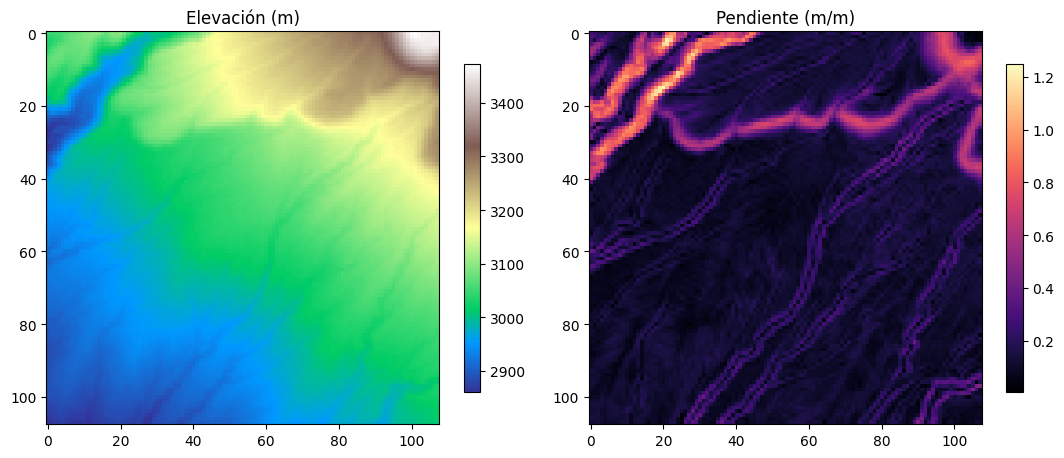

In [2]:
env = TerrenoDRLEnv(RUTA_DEM, semilla=SEMILLA)
print(f'Mapa {env.filas}x{env.columnas} | meta fija en {env.meta_fija} | obs = {env.dim_obs} números')
viz.mapa_terreno(env); plt.show()

## 1 · REINFORCE — cómo funciona (en `reinforce.py`)

- **Red de política** `PoliticaRed`: 83 → 128 → 128 → 4. La salida, tras softmax, son las
  **probabilidades** de cada acción. Misma forma que la red de DQN, pero se interpreta
  como política, no como valores Q.
- **Actuar**: muestrea una acción según esas probabilidades (exploración natural, sin
  ε-greedy).
- **Aprender** (al terminar el episodio): sube `log π(a|s) · G`, donde G es el retorno
  descontado. Acción que llevó a buen retorno → más probable. Se resta un *baseline*
  (media de retornos) para bajar la varianza.

A diferencia de DQN: **no** hay buffer de reproducción ni red objetivo, y entrena por
**episodios completos** (un update por episodio).

## 2 · Entrenar REINFORCE

ep   100 | recompensa    -17.8 | test   15% éxito,   438 pasos |    66 s
ep   200 | recompensa      7.8 | test   95% éxito,   113 pasos |    84 s
ep   300 | recompensa      8.6 | test   50% éxito,   299 pasos |   109 s
ep   400 | recompensa      9.8 | test   95% éxito,   113 pasos |   127 s
ep   500 | recompensa      9.1 | test   95% éxito,   113 pasos |   150 s
ep   600 | recompensa  -2360.8 | test   95% éxito,   113 pasos |   173 s
ep   700 | recompensa      9.2 | test   95% éxito,   113 pasos |   201 s
ep   800 | recompensa  -2039.9 | test   95% éxito,   113 pasos |   222 s
ep   900 | recompensa      9.8 | test   95% éxito,   113 pasos |   247 s
ep  1000 | recompensa      9.2 | test   95% éxito,   113 pasos |   272 s
ep  1100 | recompensa      9.4 | test   95% éxito,   113 pasos |   293 s
ep  1200 | recompensa      8.7 | test   95% éxito,   113 pasos |   316 s
ep  1300 | recompensa    -78.2 | test   35% éxito,   354 pasos |   347 s
ep  1400 | recompensa      9.7 | test   95% éxito, 

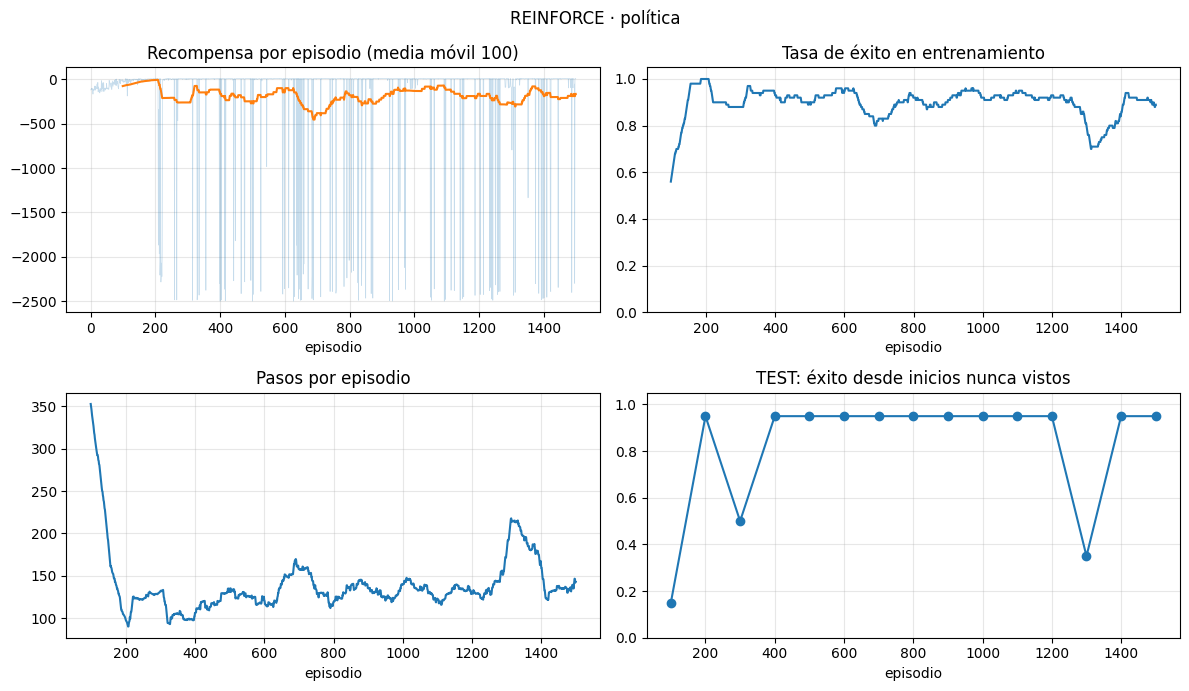

In [3]:
EPISODIOS = 1500        # baja a 500 para una prueba rápida
env = TerrenoDRLEnv(RUTA_DEM, semilla=SEMILLA)
ag_pg = AgenteREINFORCE(env.dim_obs, NUM_ACCIONES, device=device, semilla=SEMILLA)
h_pg = entrenar_pg(env, ag_pg, EPISODIOS)
viz.curvas_aprendizaje(h_pg, 'REINFORCE · política'); plt.show()

## 3 · Comparación directa: DQN (valor) vs REINFORCE (política)

Entrenamos un DQN con los mismos episodios y comparamos las curvas. Esperado: DQN
converge **suave y estable**; REINFORCE también llega alto pero con **más varianza**
(saltos), porque el gradiente de política es más ruidoso.

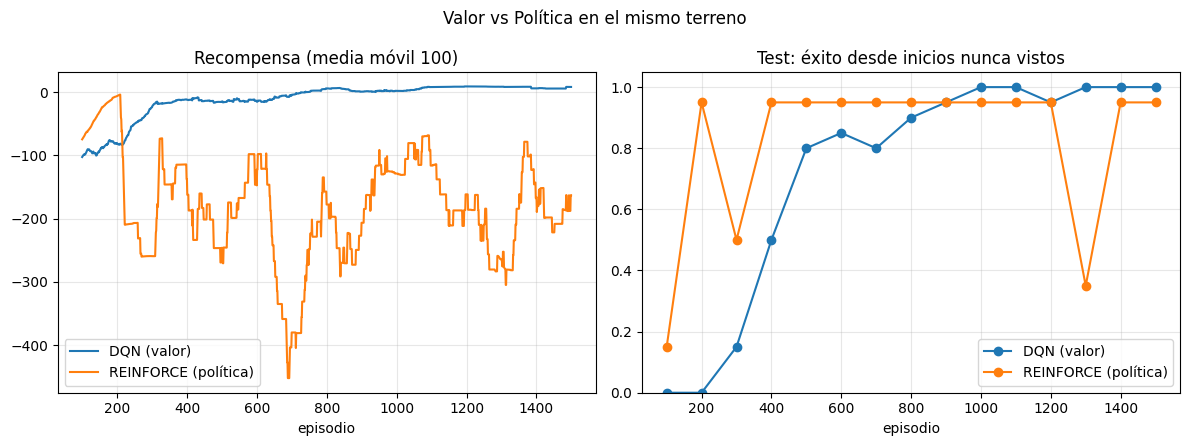

DQN       final: 100% éxito, 96 pasos
REINFORCE final: 95% éxito, 113 pasos


In [4]:
env_dqn = TerrenoDRLEnv(RUTA_DEM, semilla=SEMILLA)
ag_dqn = AgenteDQN(env_dqn.dim_obs, NUM_ACCIONES, device=device, semilla=SEMILLA)
h_dqn = entrenar(env_dqn, ag_dqn, EPISODIOS, verbose=False)

viz.comparar_curvas([h_dqn, h_pg], ['DQN (valor)', 'REINFORCE (política)'],
                    'Valor vs Política en el mismo terreno'); plt.show()
print(f"DQN       final: {h_dqn['eval_exito'][-1]:.0%} éxito, {h_dqn['eval_pasos'][-1]:.0f} pasos")
print(f"REINFORCE final: {h_pg['eval_exito'][-1]:.0%} éxito, {h_pg['eval_pasos'][-1]:.0f} pasos")

## 4 · Conclusión (para el informe)

Ambas familias resuelven el problema en el mismo terreno, con trade-offs distintos:

| | DQN (basado en valor) | REINFORCE (basado en política) |
|---|---|---|
| Qué aprende | Q(s,a); acción = argmax | π(a\|s); probabilidades de acción |
| Política | determinista | **estocástica** |
| Exploración | ε-greedy | muestreo de la política |
| Estabilidad | alta (replay + θ⁻) | **menor** (más varianza) |
| Componentes | buffer + red objetivo | ninguno (más simple) |

Los dos convergen a alta tasa de éxito, pero DQN lo hace de forma más **estable** y
REINFORCE con más **ruido** — el comportamiento clásico de cada familia. Cubrimos así
las dos ramas principales de la taxonomía de la clase 5.1 (valor y política).